In this project we will build a nice web app that allows you to swap out the background of a subject and substitute it with an image generated by Stable Diffusion through a text prompt:

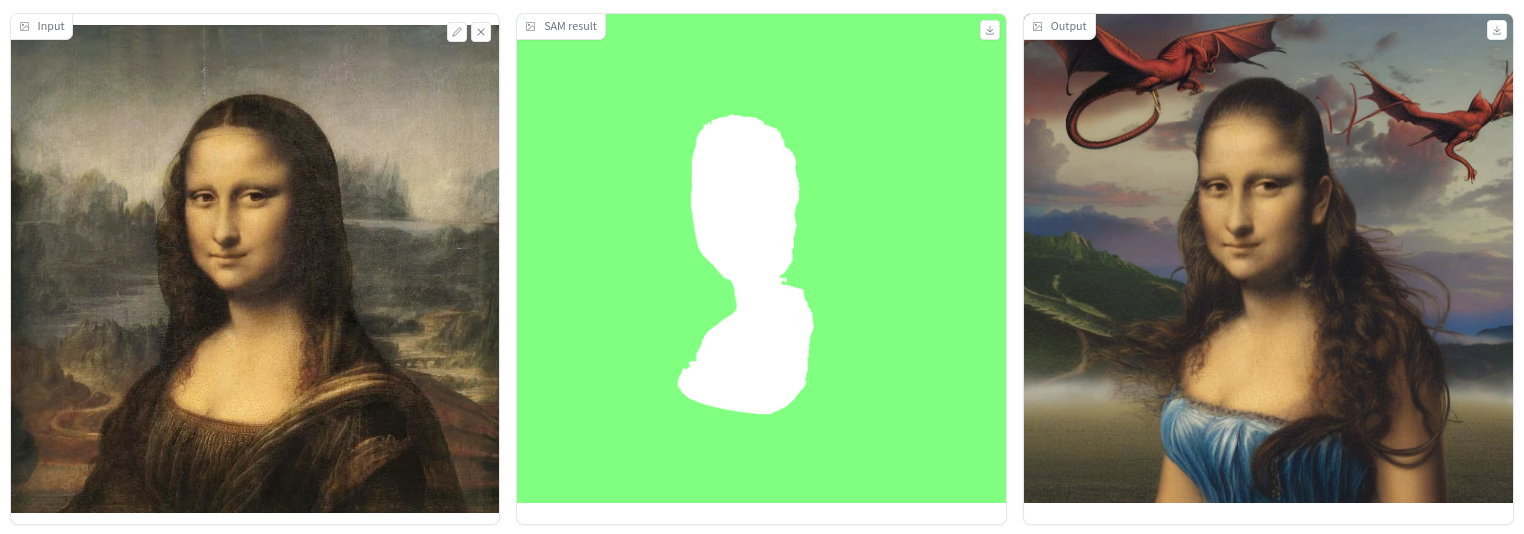

Let's start by importing what we need:

In [2]:
pip install git+https://github.com/facebookresearch/segment-anything.git

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-0n6acv2w
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-0n6acv2w
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment-anything: filename=segment_anything-1.0-py3-none-any.whl size=36587 sha256=e5dc9bebdd20f92fa93977f064ae4b4474c5a1a2e0d4589ed9472387af14891c
  Stored in directory: /tmp/pip-ephem-wheel-cache-yf58kexy/wheels/10/cf/59/9ccb2f0a1bcc81d4fbd0e501680b5d088d690c6cfbc02dc99d
Successfully built segment-anything
Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import numpy as np
import requests
import os

from PIL import Image
from transformers import SamModel, SamProcessor
from diffusers import DiffusionPipeline, AutoPipelineForText2Image, AutoPipelineForInpainting
from diffusers.utils import load_image, make_image_grid
from segment_anything import sam_model_registry, SamPredictor

## SAM

Complete the following cell by loading the pretrained SAM from Facebook/Meta. Remember to:

1. Move the model to the GPU by adding `.to("cuda")`
2. Add the option `torch_dtype=torch.float16` to your call of AutoPipelineForInpainting.from_pretrained

This cell might take a couple of minutes to load.

In [4]:
# Get the current working directory
print("Current Working Directory:", os.getcwd())

# List files and directories in the working directory
print("Files and Directories:", os.listdir(os.getcwd()))


Current Working Directory: /workspace/Computer-Vision-and-Generative-AI-Project/starter
Files and Directories: ['app.py', 'starter.ipynb', 'README.md', 'monalisa.png', '__pycache__', 'car.png', '.ipynb_checkpoints', 'sam_vit_h_4b8939.pth', 'dragon.jpeg']


In [5]:
# URL of the SAM model checkpoint
url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
output_path = "./sam_vit_h_4b8939.pth"  # Save in the current directory

# Download the checkpoint
print("Downloading SAM model checkpoint...")
response = requests.get(url)
with open(output_path, "wb") as f:
    f.write(response.content)
print("SAM model checkpoint downloaded successfully!")


SAM model checkpoint downloaded successfully!


In [6]:
# Path to the SAM checkpoint file
sam_checkpoint = "./sam_vit_h_4b8939.pth"

# Load the SAM model and move it to GPU
model = sam_model_registry["vit_h"](checkpoint=sam_checkpoint).to("cuda", dtype=torch.float16)

# Initialize the SAM predictor
predictor = SamPredictor(model)

print("SAM model and predictor loaded successfully!")

SAM model and predictor loaded successfully!


In [7]:
pip show segment-anything

Name: segment-anything
Version: 1.0
Summary: 
Home-page: 
Author: 
Author-email: 
License: 
Location: /home/student/.local/lib/python3.10/site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.


### Get the mask

Now that you have loaded SAM, complete the following function that uses SAM to produce a segmentation mask:

In [8]:
def mask_to_rgb(mask):
    bg_transparent = np.zeros(mask.shape + (4,), dtype=np.uint8)
    bg_transparent[mask == 1] = [0, 255, 0, 127]  # Green with transparency
    return bg_transparent

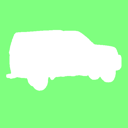

In [9]:
def get_processed_inputs(image, input_points):
    # Set the image for the predictor
    predictor.set_image(np.array(image))

    input_points = np.array(input_points[0], dtype=np.float32)  
    point_labels = np.ones(input_points.shape[0], dtype=np.int32)  

    # Convert inputs to tensors with correct data type
    # Note: We're keeping these on CPU for now
    input_points = torch.tensor(input_points, dtype=torch.float32)
    point_labels = torch.tensor(point_labels, dtype=torch.long)  # Changed to long

    # Predict masks
    masks, scores, logits = predictor.predict(
        point_coords=input_points.numpy(),
        point_labels=point_labels.numpy(),
        multimask_output=True
    )

    # Select the best mask based on confidence scores
    best_mask = masks[scores.argmax()]

    # Invert the mask for inpainting
    return ~best_mask

predictor.model = predictor.model.float()

raw_image = Image.open("car.png").convert("RGB").resize((512, 512))
input_points = [[[150, 170], [300, 250]]]  # Example points

# Generate the mask
mask = get_processed_inputs(raw_image, input_points)

# Visualize the mask
Image.fromarray(mask_to_rgb(mask)).resize((128, 128))


Now let's test what we have done so far. By executing this cell you should get a visualization of the mask for the following car:

<img src='car.png' width="200px"></img>

Let's see what happens in this cell:
1. We open the image of the car and **we resize it to 512 by 512 pixels** (a square image). This makes things simpler for this project
2. We define a few points on the image that indicate where the car is
3. We use the function we have defined to generate a mask using SAM
4. We visualize the mask

The mask should look like this:

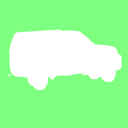

If it doesn't or you get errors, double check the code you have completed above and fix it before moving on.

## Inpainting

Now that we have completed the SAM setup, let's move to the inpainting setup.

Let's start by loading our inpainting pipeline. We will use the `diffusers/stable-diffusion-xl-1.0-inpainting-0.1` pretrained model and the `AutoPipelineForInpainting` as we have seen in our `diffusers` demo in Lesson 5.

Complete the following code and run it (it might take a few minutes to run):

> **NOTE**: you will probably see a warning similar to ``The config attributes {'decay'...``. Please ignore it. It is a warning generated by the diffusers library that does not constitute a problem for our application

In [10]:
pipeline = AutoPipelineForInpainting.from_pretrained(
    "diffusers/stable-diffusion-xl-1.0-inpainting-0.1",
    torch_dtype=torch.float16
).to("cuda")

# Enable model efficiency
pipeline.enable_model_cpu_offload()


model_index.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

text_encoder/config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

text_encoder_2/config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

scheduler/scheduler_config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

tokenizer_2/vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


In [11]:
def inpaint(raw_image, input_mask, prompt, negative_prompt=None, seed=74294536, cfgs=7):
    mask_image = Image.fromarray(input_mask)
    rand_gen = torch.manual_seed(seed)

    # Generate the inpainted image
    image = pipeline(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=raw_image,
        mask_image=mask_image,
        generator=rand_gen,
        guidance_scale=cfgs
    ).images[0]

    return image


  0%|          | 0/49 [00:00<?, ?it/s]

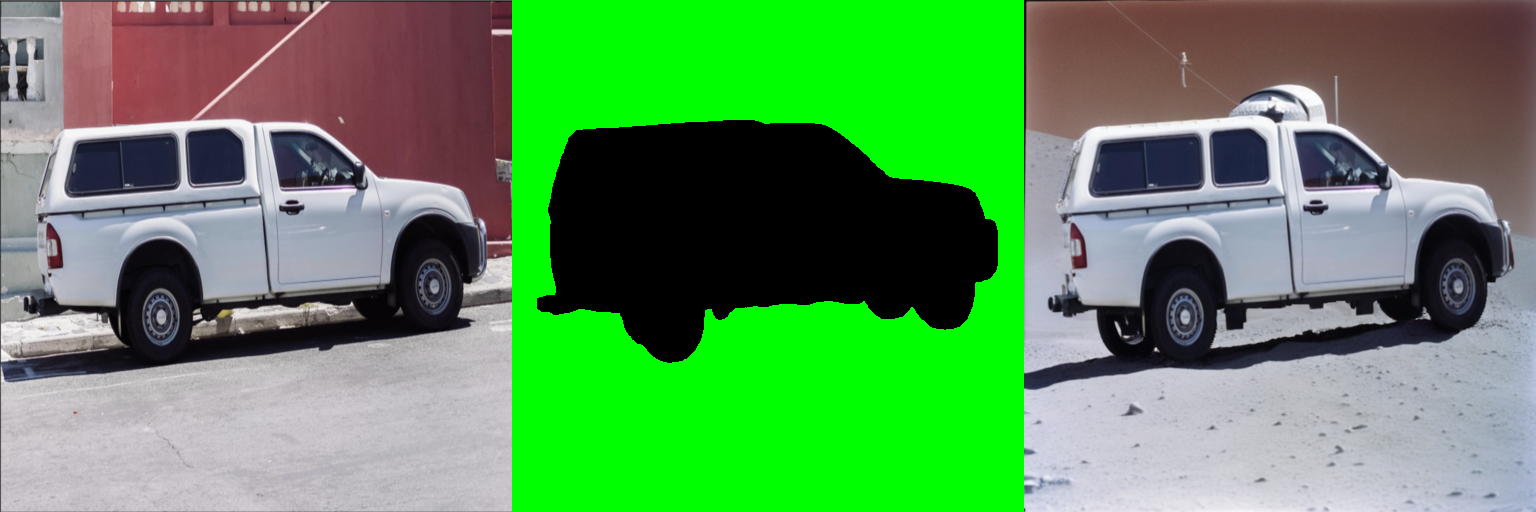

In [12]:
prompt = "a car driving on Mars. Studio lights, 1970s"
negative_prompt = "artifacts, low quality, distortion"

image = inpaint(raw_image, mask, prompt, negative_prompt)

from diffusers.utils import make_image_grid

fig = make_image_grid([raw_image, Image.fromarray(mask_to_rgb(mask)), image.resize((512, 512))], rows=1, cols=3)
fig


## Interactive app

To make things a bit more fun, we have prepared an interactive app for you that uses the code you have completed and allow you to upload an image, run SAM, and generate the new background through a text prompt.

Simply execute the following cell. The output will contain a preview of the app: **DO NOT USE IT**. Instead, you will also see a link similar to this:

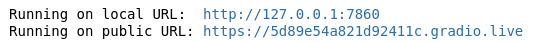

Click on the second link (the public URL), from there you will be able to use the app much more comfortably.

> NOTE: if for any reason you need to stop the app, click on the stop icon of the jupyter interface:   then **execute the next cell containing the code `my_app.close`**


In [ ]:
import app

my_app = app.generate_app(get_processed_inputs, inpaint)


Running on local URL:  http://127.0.0.1:7860
IMPORTANT: You are using gradio version 3.50.2, however version 4.44.1 is available, please upgrade.
--------
Running on public URL: https://f42d56aeb6f26d173a.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/home/student/.local/lib/python3.10/site-packages/gradio/queueing.py", line 407, in call_prediction
    output = await route_utils.call_process_api(
  File "/home/student/.local/lib/python3.10/site-packages/gradio/route_utils.py", line 226, in call_process_api
    output = await app.get_blocks().process_api(
  File "/home/student/.local/lib/python3.10/site-packages/gradio/blocks.py", line 1550, in process_api
    result = await self.call_function(
  File "/home/student/.local/lib/python3.10/site-packages/gradio/blocks.py", line 1185, in call_function
    prediction = await anyio.to_thread.run_sync(
  File "/home/student/.local/lib/python3.10/site-packages/anyio/to_thread.py", line 56, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
  File "/home/student/.local/lib/python3.10/site-packages/anyio/_backends/_asyncio.py", line 2144, in run_sync_in_worker_thread
    return await future
  File "/home/student/.local/lib/py

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

In [ ]:
my_app.close()